In [6]:
import numpy as np
import pandas as pd
import seaborn as sns

In [ ]:
# KNN Implementation from scratch for Binary Classification

class KNNClassifier:
    def __init__(self, k=3):
        self.k = k
        
    def _euclidean_dist(self, x1, x2):
        d = np.sqrt(np.sum((x1-x2) ** 2))
        return d
        
    def fit(self, X, y): # Lazy Learner - stores the data
        self.X_train = X
        self.y_train = y
            
            
    def _predict_one(self, x): # for one data point
        distances = [self._euclidean_dist(x, x_train) for x_train in self.X_train]
         
        # Get indices of k nearest neighbors    
        knn_indices = np.argsort(distances)[:self.k]
            
        knn_classes = [self.y_train[i] for i in knn_indices]
            
        majority_class = np.argmax(np.bincount(knn_classes))
        return majority_class
        
    def predict(self, X): # for all data points
        y_pred = [self._predict_one(x) for x in X]
        return y_pred

In [23]:
# Data 
X_train = np.array([
    [1,2],
    [2,3],
    [3,3],
    [6,5],
    [7,7]
])

y_train = np.array([0, 0, 0, 1, 1])

X_test = np.array([
    [2,2],
    [6,6]
])

model = KNNClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(np.array(y_pred))

[0 1]


<Axes: xlabel='x1', ylabel='x2'>

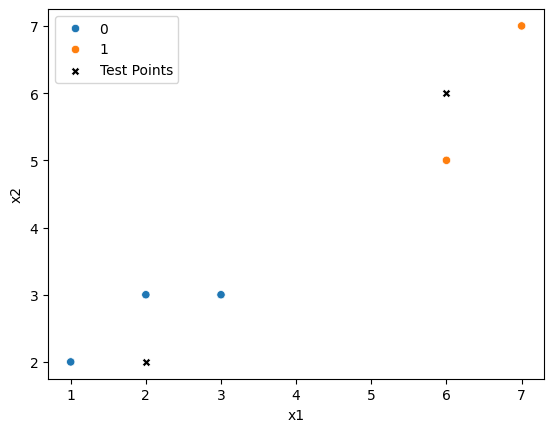

In [13]:
# Visualize
X_train_df = pd.DataFrame(X_train, columns=["x1","x2"])
X_train_df["label"] = y_train

sns.scatterplot(
    data = X_train_df,
    x = "x1",
    y = "x2",
    hue = "label"
)

X_test_df = pd.DataFrame(X_test, columns=["x1","x2"])
sns.scatterplot(
    data = X_test_df,
    x = "x1",
    y = "x2",
    color = "black",
    marker = "X",
    label = "Test Points"
)

In [ ]:
# KNN Regressor

class KNNRegressor:
    def __init__(self, k=3):
        self.k = k
        
    def _euclidean_dist(self, x1, x2):
        d = np.sqrt(np.sum((x1-x2) ** 2))
        return d
        
    def fit(self, X, y): # Lazy Learner - stores the data
        self.X_train = X
        self.y_train = y
            
            
    def _predict_one(self, x): # for one data point
        distances = [self._euclidean_dist(x, x_train) for x_train in self.X_train]
            
        knn_indices = np.argsort(distances)[:self.k]
            
        # Get k nearest target values
        k_nearest_values = self.y_train[knn_indices]

        # Return mean of neighbors
        return np.mean(k_nearest_values)
        
        
    def predict(self, X): # for all data points
        y_pred = [self._predict_one(x) for x in X]
        return y_pred

In [28]:
X_train = np.array([[1], [2], [3], [4], [5]])
y_train = np.array([2, 4, 6, 8, 10])

X_test = [[1.5], [3.5], [6]]

model = KNNRegressor()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(np.array(y_pred))

[4. 6. 8.]


<Axes: xlabel='x', ylabel='y'>

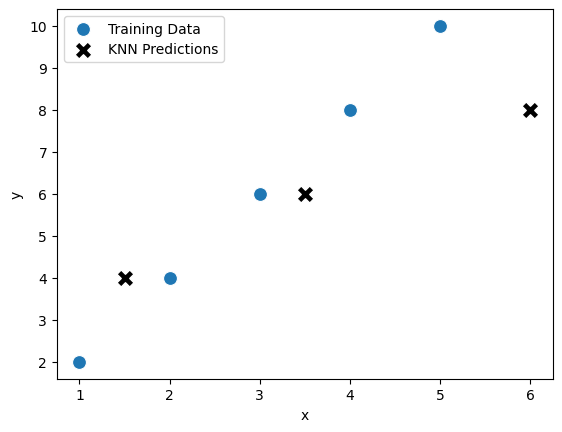

In [ ]:
# Prepare Training Data
train_df = pd.DataFrame({
    'x': X_train.flatten(),
    'y': y_train,
    'type': 'Train'
})

# Prepare Test Data (using predictions for the y-axis)
test_df = pd.DataFrame({
    'x': [i[0] for i in X_test],
    'y': y_pred,
    'type': 'Test Prediction'
})

sns.scatterplot(
    data=train_df, 
    x='x', 
    y='y', 
    s=100, 
    label='Training Data'
)

# Plot test predictions with a distinct marker
sns.scatterplot(
    data=test_df, 
    x='x', 
    y='y', 
    color='black', 
    marker='X', 
    s=150, 
    label='KNN Predictions'
)